# Healthcare Analytics for Doctor Visits

## 1. Project Overview

This project focuses on analyzing a healthcare dataset to understand patterns in doctor visits. The analysis explores demographic, health, illness, activity, socioeconomic, insurance, and chronic-condition variables.

Using Python and data visualization techniques, the project identifies relationships and patterns that may help in understanding healthcare utilization within the dataset.

## 2. Problem Statement

Doctor visits can vary across individuals depending on factors such as illness, health status, age, activity limitations, socioeconomic conditions, and chronic health conditions.

The objective of this project is to analyze the given healthcare dataset and identify the factors and patterns associated with the number of doctor visits.

The analysis aims to understand the distribution of doctor visits and examine how different demographic, health, socioeconomic, insurance, and chronic-condition variables are related to healthcare utilization.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")

## 3. Data Loading & Understanding

In [57]:
df = pd.read_csv(
    "1776250375-P2-Healthcare Analytics for Doctor Visits (1) (1).csv"
)

df.head()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [58]:
df.tail()

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
5185,5186,0,female,0.22,0.55,0,0,0,no,no,no,no,no
5186,5187,0,male,0.27,1.30,0,0,1,no,no,no,no,no
5187,5188,0,female,0.37,0.25,1,0,1,no,no,yes,no,no
5188,5189,0,female,0.52,0.65,0,0,0,no,no,no,no,no
5189,5190,0,male,0.72,0.25,0,0,0,no,no,yes,no,no


In [59]:
df.shape

(5190, 13)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   object 
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   object 
 9   freepoor    5190 non-null   object 
 10  freerepat   5190 non-null   object 
 11  nchronic    5190 non-null   object 
 12  lchronic    5190 non-null   object 
dtypes: float64(2), int64(5), object(6)
memory usage: 527.2+ KB


In [61]:
df.describe()

,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [62]:
df.describe(include='all')

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
count,5190.000000,5190.000000,5190,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190,5190,5190,5190,5190
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,female,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no
freq,NaN,NaN,2702,NaN,NaN,NaN,NaN,NaN,2892,4968,4099,3098,4585
mean,2595.500000,0.301734,NaN,0.406385,0.583160,1.431985,0.861850,1.217534,NaN,NaN,NaN,NaN,NaN
std,1498.368279,0.798134,NaN,0.204782,0.368907,1.384152,2.887628,2.124266,NaN,NaN,NaN,NaN,NaN
min,1.000000,0.000000,NaN,0.190000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
25%,1298.250000,0.000000,NaN,0.220000,0.250000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
50%,2595.500000,0.000000,NaN,0.320000,0.550000,1.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN
75%,3892.750000,0.000000,NaN,0.620000,0.900000,2.000000,0.000000,2.000000,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

In [63]:
df.isnull().sum()

Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64

In [64]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum().values,
    'Missing %': (df.isnull().sum().values / len(df) * 100)
})

missing_data

,Column,Missing Values,Missing %
0,Unnamed: 0,0,0.0
1,visits,0,0.0
2,gender,0,0.0
3,age,0,0.0
4,income,0,0.0
5,illness,0,0.0
6,reduced,0,0.0
7,health,0,0.0
8,private,0,0.0
9,freepoor,0,0.0


In [65]:
df.duplicated().sum()

0

In [66]:
df = df.drop(columns=['Unnamed: 0'])

In [67]:
df.head()

,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [68]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


visits
[1 2 3 4 8 5 7 6 9 0]

gender
['female' 'male']

age
[0.19 0.22 0.27 0.32 0.37 0.42 0.47 0.52 0.57 0.62 0.67 0.72]

income
[0.55 0.45 0.9  0.15 0.35 0.65 0.25 0.   0.06 1.1  0.75 0.01 1.3  1.5 ]

illness
[1 3 2 5 4 0]

reduced
[ 4  2  0  5  1 13  7  3 14  6  8  9 10 12 11]

health
[ 1  0  9  2  6  5  7 11  4 12  3 10  8]

private
['yes' 'no']

freepoor
['no' 'yes']

freerepat
['no' 'yes']

nchronic
['no' 'yes']

lchronic
['no' 'yes']


## 5. Exploratory Data Analysis

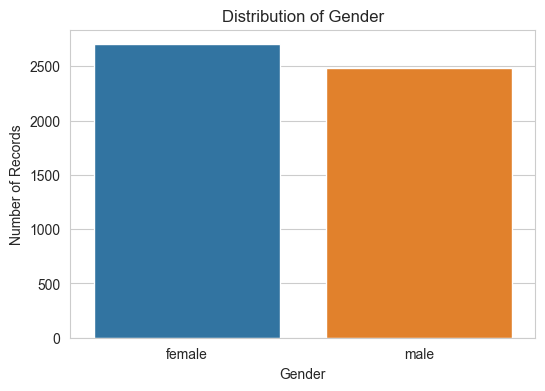

In [69]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='gender',
    hue='gender',
    legend=False
)

plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Records')

plt.show()

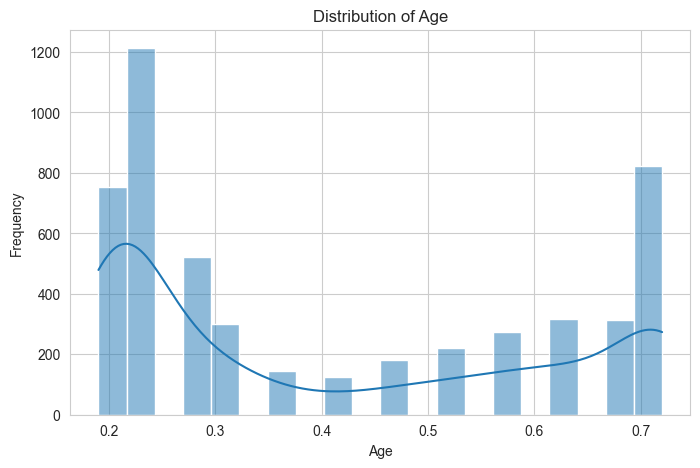

In [70]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True
)

plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

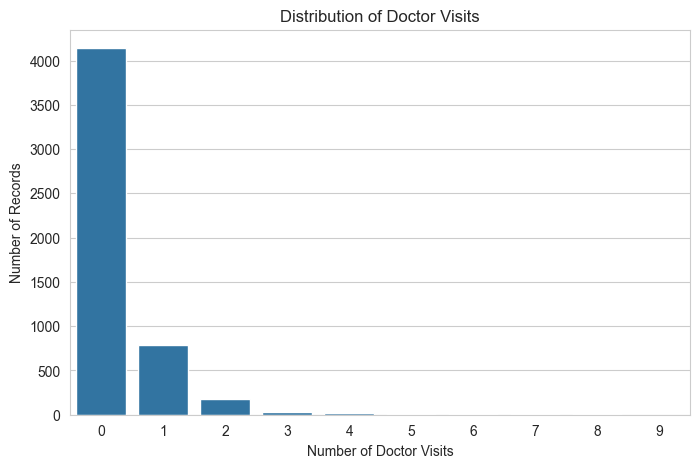

In [71]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='visits'
)

plt.title('Distribution of Doctor Visits')
plt.xlabel('Number of Doctor Visits')
plt.ylabel('Number of Records')

plt.show()

In [72]:
visit_distribution = df['visits'].value_counts().sort_index()

visit_distribution

visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

In [73]:
visit_percentage = (
    df['visits']
    .value_counts(normalize=True)
    .sort_index() * 100
)

visit_percentage

visits
0    79.788054
1    15.067437
2     3.352601
3     0.578035
4     0.462428
5     0.173410
6     0.231214
7     0.231214
8     0.096339
9     0.019268
Name: proportion, dtype: float64

## 6. Bivariate & Multivariate Analysis

In [74]:
gender_analysis = (
    df.groupby('gender')['visits']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

gender_analysis

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


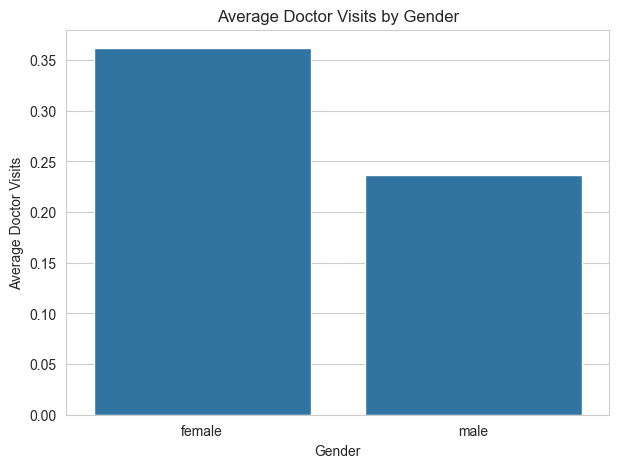

In [75]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_analysis,
    x='gender',
    y='mean'
)

plt.title('Average Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Doctor Visits')

plt.show()

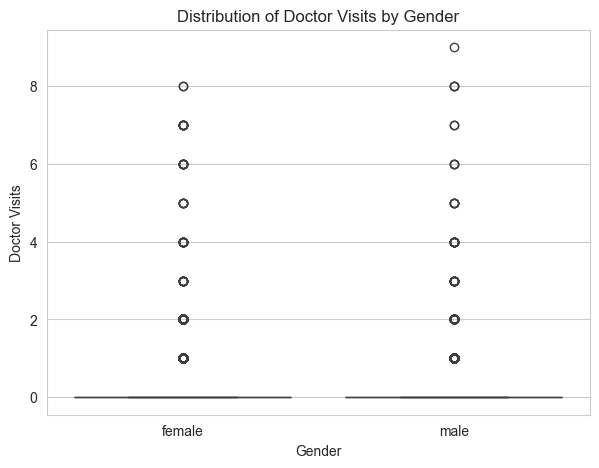

In [76]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='gender',
    y='visits',
    hue='gender',
    legend=False
)

plt.title('Distribution of Doctor Visits by Gender')
plt.xlabel('Gender')
plt.ylabel('Doctor Visits')

plt.show()

In [77]:
illness_analysis = (
    df.groupby('illness')['visits']
      .agg(['count', 'mean', 'median'])
      .reset_index()
)

illness_analysis

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


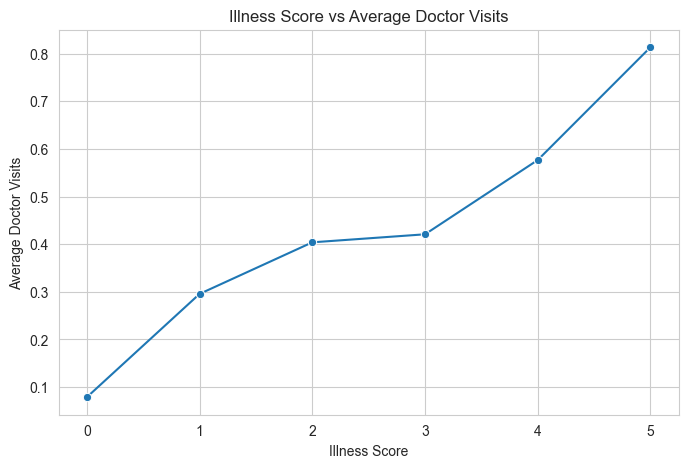

In [78]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=illness_analysis,
    x='illness',
    y='mean',
    marker='o'
)

plt.title('Illness Score vs Average Doctor Visits')
plt.xlabel('Illness Score')
plt.ylabel('Average Doctor Visits')

plt.show()

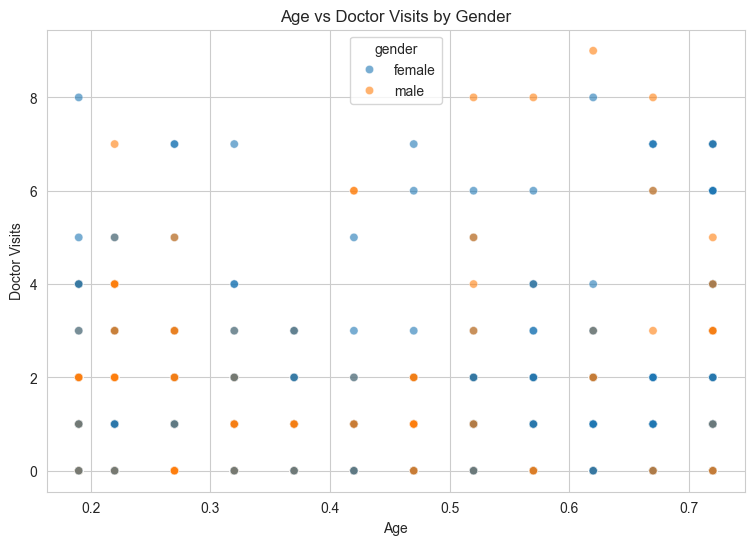

In [79]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='age',
    y='visits',
    hue='gender',
    alpha=0.6
)

plt.title('Age vs Doctor Visits by Gender')
plt.xlabel('Age')
plt.ylabel('Doctor Visits')

plt.show()

In [80]:
health_analysis = (
    df.groupby("health")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(health_analysis)

,health,count,mean,median
0,0,3026,0.199273,0.0
1,1,823,0.335358,0.0
2,2,446,0.381166,0.0
3,3,273,0.417582,0.0
4,4,187,0.534759,0.0
5,5,132,0.530303,0.0
6,6,104,0.625000,0.0
7,7,61,0.918033,0.0
8,8,42,0.476190,0.0
9,9,32,0.656250,0.0


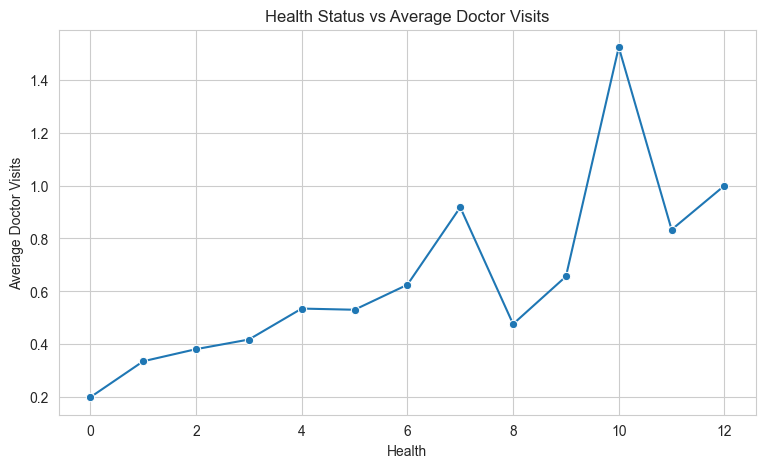

In [81]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=health_analysis,
    x="health",
    y="mean",
    marker="o"
)

plt.title("Health Status vs Average Doctor Visits")
plt.xlabel("Health")
plt.ylabel("Average Doctor Visits")

plt.show()

In [82]:
reduced_analysis = (
    df.groupby("reduced")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(reduced_analysis)

,reduced,count,mean,median
0,0,4454,0.183880,0.0
1,1,177,0.355932,0.0
2,2,108,0.574074,0.0
3,3,74,1.094595,1.0
4,4,45,0.800000,1.0
5,5,40,1.275000,1.0
6,6,17,1.176471,1.0
7,7,38,1.184211,1.0
8,8,17,1.176471,1.0
9,9,7,1.714286,1.0


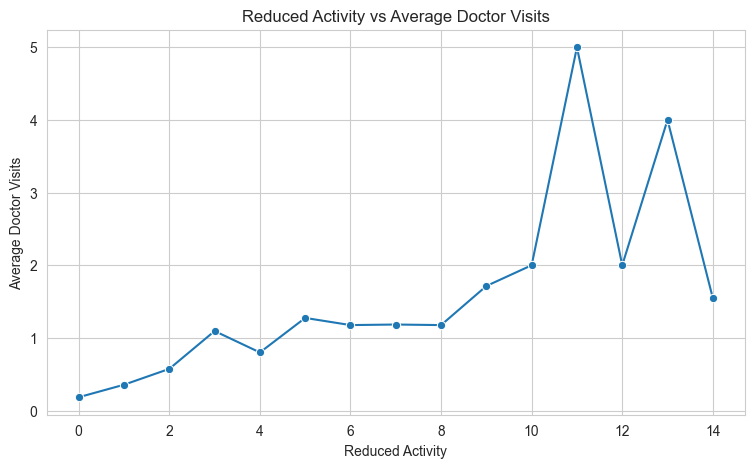

In [83]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=reduced_analysis,
    x="reduced",
    y="mean",
    marker="o"
)

plt.title("Reduced Activity vs Average Doctor Visits")
plt.xlabel("Reduced Activity")
plt.ylabel("Average Doctor Visits")

plt.show()

In [84]:
income_analysis = (
    df.groupby("income")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(income_analysis)

,income,count,mean,median
0,0.00,79,0.367089,0.0
1,0.01,35,0.485714,0.0
2,0.06,80,0.200000,0.0
3,0.15,249,0.349398,0.0
4,0.25,1195,0.420921,0.0
5,0.35,462,0.359307,0.0
6,0.45,400,0.305000,0.0
7,0.55,467,0.252677,0.0
8,0.65,455,0.246154,0.0
9,0.75,441,0.244898,0.0


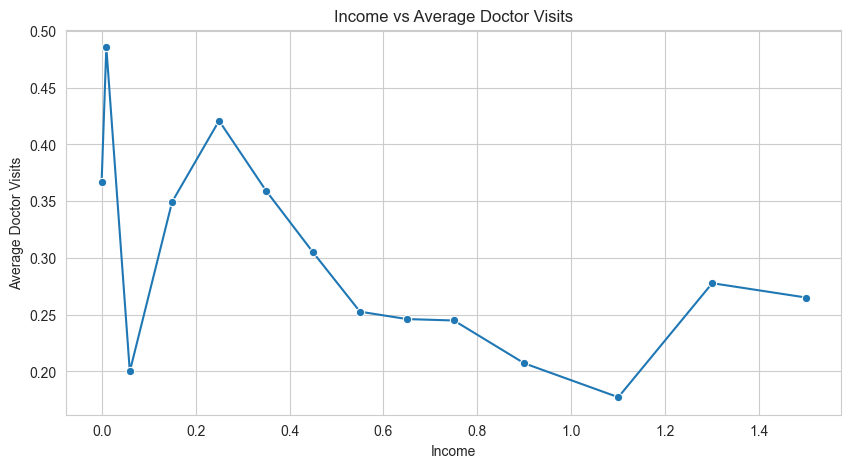

In [85]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=income_analysis,
    x="income",
    y="mean",
    marker="o"
)

plt.title("Income vs Average Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Average Doctor Visits")

plt.show()

In [86]:
nchronic_analysis = (
    df.groupby("nchronic")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(nchronic_analysis)

,nchronic,count,mean,median
0,no,3098,0.272111,0.0
1,yes,2092,0.345602,0.0


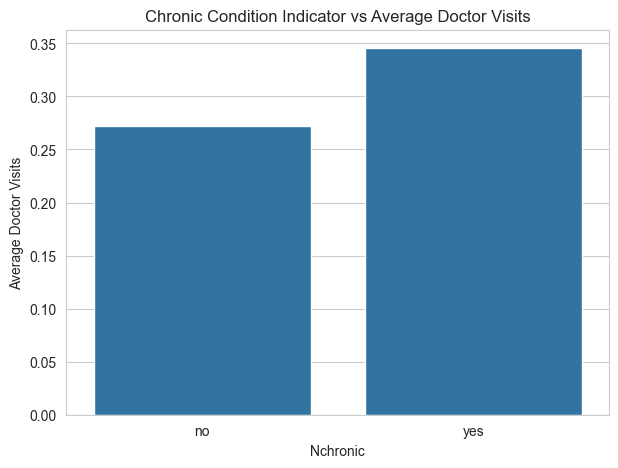

In [87]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=nchronic_analysis,
    x="nchronic",
    y="mean"
)

plt.title("Chronic Condition Indicator vs Average Doctor Visits")
plt.xlabel("Nchronic")
plt.ylabel("Average Doctor Visits")

plt.show()

In [88]:
lchronic_analysis = (
    df.groupby("lchronic")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

display(lchronic_analysis)

,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


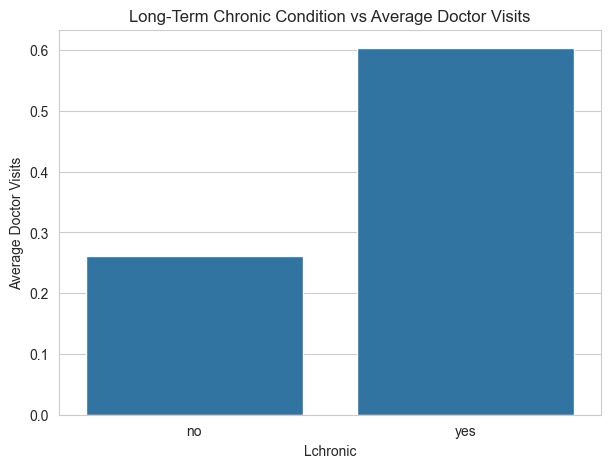

In [89]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=lchronic_analysis,
    x="lchronic",
    y="mean"
)

plt.title("Long-Term Chronic Condition vs Average Doctor Visits")
plt.xlabel("Lchronic")
plt.ylabel("Average Doctor Visits")

plt.show()

In [90]:
def analyze_category(column):

    analysis = (
        df.groupby(column)["visits"]
          .agg(["count", "mean", "median"])
          .reset_index()
    )

    display(analysis)

    plt.figure(figsize=(7, 5))

    sns.barplot(
        data=analysis,
        x=column,
        y="mean"
    )

    plt.title(f"{column} vs Average Doctor Visits")
    plt.xlabel(column)
    plt.ylabel("Average Doctor Visits")

    plt.show()

,private,count,mean,median
0,no,2892,0.307400,0.0
1,yes,2298,0.294604,0.0


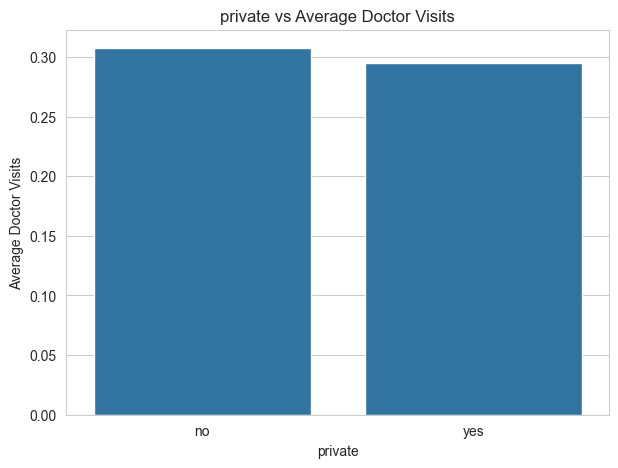

In [91]:
analyze_category("private")

,freepoor,count,mean,median
0,no,4968,0.308172,0.0
1,yes,222,0.157658,0.0


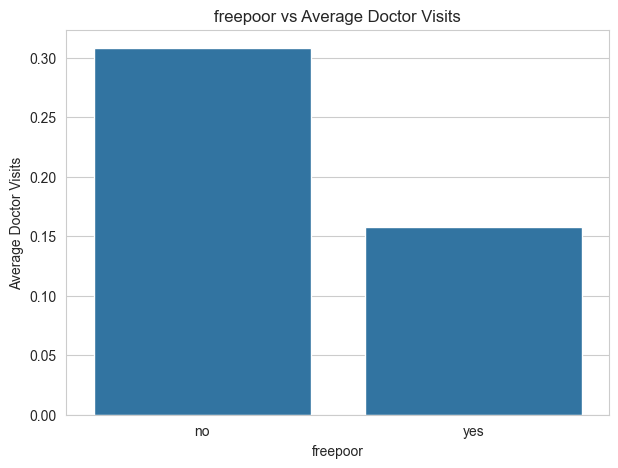

In [92]:
analyze_category("freepoor")

,freerepat,count,mean,median
0,no,4099,0.257868,0.0
1,yes,1091,0.466544,0.0


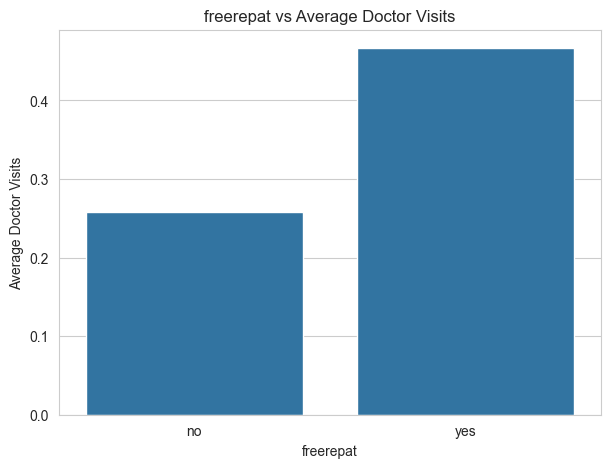

In [93]:
analyze_category("freerepat")

In [94]:
numeric_columns = [
    "visits",
    "age",
    "income",
    "illness",
    "reduced",
    "health"
]

correlation_matrix = df[numeric_columns].corr()

correlation_matrix

,visits,age,income,illness,reduced,health
visits,1.000000,0.124537,-0.076840,0.223552,0.418954,0.193272
age,0.124537,1.000000,-0.271073,0.204984,0.094745,0.018616
income,-0.076840,-0.271073,1.000000,-0.148812,-0.047545,-0.085790
illness,0.223552,0.204984,-0.148812,1.000000,0.218116,0.360110
reduced,0.418954,0.094745,-0.047545,0.218116,1.000000,0.280208
health,0.193272,0.018616,-0.085790,0.360110,0.280208,1.000000


## 7. Correlation Analysis

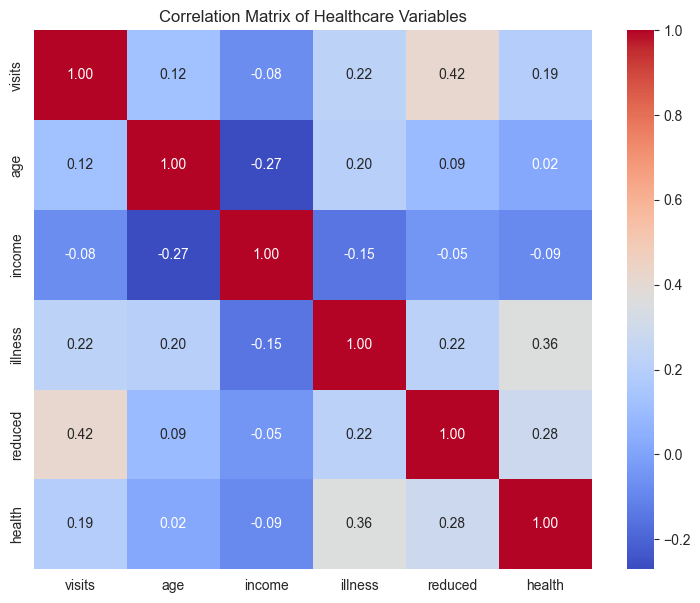

In [95]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Healthcare Variables")

plt.show()

In [96]:
visit_correlations = (
    correlation_matrix["visits"]
    .drop("visits")
    .sort_values(ascending=False)
)

visit_correlations

reduced    0.418954
illness    0.223552
health     0.193272
age        0.124537
income    -0.076840
Name: visits, dtype: float64

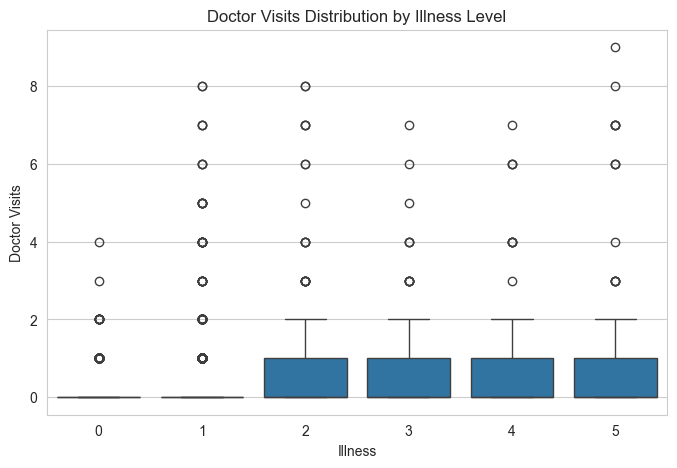

In [97]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="illness",
    y="visits"
)

plt.title("Doctor Visits Distribution by Illness Level")
plt.xlabel("Illness")
plt.ylabel("Doctor Visits")

plt.show()

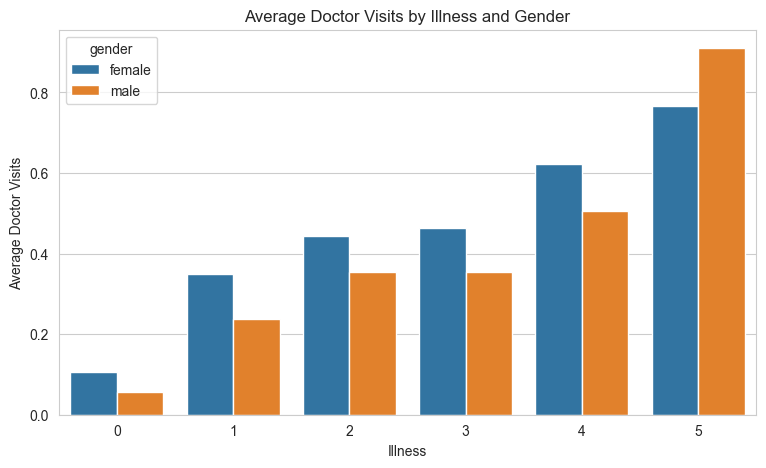

In [98]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="illness",
    y="visits",
    hue="gender",
    errorbar=None
)

plt.title("Average Doctor Visits by Illness and Gender")
plt.xlabel("Illness")
plt.ylabel("Average Doctor Visits")

plt.show()

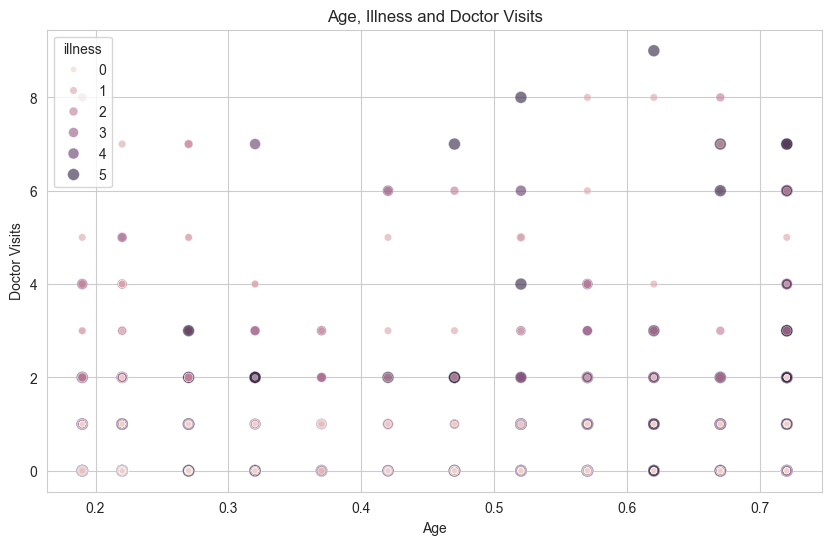

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="visits",
    hue="illness",
    size="illness",
    alpha=0.6
)

plt.title("Age, Illness and Doctor Visits")
plt.xlabel("Age")
plt.ylabel("Doctor Visits")

plt.show()

In [100]:
summary = {
    "Total Records": len(df),
    "Average Doctor Visits": df["visits"].mean(),
    "Median Doctor Visits": df["visits"].median(),
    "Maximum Doctor Visits": df["visits"].max(),
    "Average Age Value": df["age"].mean(),
    "Average Income Value": df["income"].mean(),
    "Average Illness Value": df["illness"].mean(),
    "Average Reduced Activity": df["reduced"].mean(),
    "Average Health Value": df["health"].mean()
}

summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df

,Metric,Value
0,Total Records,5190.000000
1,Average Doctor Visits,0.301734
2,Median Doctor Visits,0.000000
3,Maximum Doctor Visits,9.000000
4,Average Age Value,0.406385
5,Average Income Value,0.583160
6,Average Illness Value,1.431985
7,Average Reduced Activity,0.861850
8,Average Health Value,1.217534


In [101]:
print("Duplicate rows after removing record ID:", df.duplicated().sum())

Duplicate rows after removing record ID: 1320


In [102]:
visit_summary = {
    "Total Records": len(df),
    "Average Visits": df["visits"].mean(),
    "Median Visits": df["visits"].median(),
    "Maximum Visits": df["visits"].max(),
    "Records with 0 Visits": (df["visits"] == 0).sum(),
    "Percentage with 0 Visits": (df["visits"] == 0).mean() * 100
}

pd.DataFrame(
    visit_summary.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Total Records,5190.000000
1,Average Visits,0.301734
2,Median Visits,0.000000
3,Maximum Visits,9.000000
4,Records with 0 Visits,4141.000000
5,Percentage with 0 Visits,79.788054


In [103]:
gender_summary = (
    df.groupby("gender")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

gender_summary

,gender,count,mean,median
0,female,2702,0.361954,0.0
1,male,2488,0.236334,0.0


In [104]:
illness_summary = (
    df.groupby("illness")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

illness_summary

,illness,count,mean,median
0,0,1554,0.078507,0.0
1,1,1638,0.295482,0.0
2,2,946,0.403805,0.0
3,3,542,0.420664,0.0
4,4,274,0.576642,0.0
5,5,236,0.813559,0.0


In [105]:
df[["visits", "reduced"]].corr()

,visits,reduced
visits,1.000000,0.418954
reduced,0.418954,1.000000


In [106]:
chronic_summary = (
    df.groupby("lchronic")["visits"]
      .agg(["count", "mean", "median"])
      .reset_index()
)

chronic_summary

,lchronic,count,mean,median
0,no,4585,0.261941,0.0
1,yes,605,0.603306,0.0


In [107]:
correlation_ranking = (
    df[
        ["visits", "age", "income", "illness", "reduced", "health"]
    ]
    .corr()["visits"]
    .drop("visits")
    .sort_values(ascending=False)
    .reset_index()
)

correlation_ranking.columns = ["Variable", "Correlation with Visits"]

correlation_ranking

,Variable,Correlation with Visits
0,reduced,0.418954
1,illness,0.223552
2,health,0.193272
3,age,0.124537
4,income,-0.076840


In [108]:
findings = pd.DataFrame({
    "Factor": [
        "Overall Visit Pattern",
        "Gender",
        "Illness",
        "Reduced Activity",
        "Long-Term Chronic Condition",
        "Age",
        "Income"
    ],
    
    "Finding": [
        "Most records have zero doctor visits",
        "Female records have higher average visits than male records",
        "Higher illness values are associated with higher average visits",
        "Strongest positive correlation with doctor visits among analyzed numerical variables",
        "Records marked yes have higher average visits",
        "Weak positive correlation with visits",
        "Very weak negative correlation with visits"
    ],
    
    "Evidence": [
        "79.79% of records have zero visits",
        "0.362 vs 0.236 average visits",
        "0.079 at illness 0 → 0.814 at illness 5",
        "Correlation ≈ 0.419",
        "0.603 vs 0.262 average visits",
        "Correlation ≈ 0.125",
        "Correlation ≈ -0.077"
    ]
})

findings

,Factor,Finding,Evidence
0,Overall Visit Pattern,Most records have zero doctor visits,79.79% of records have zero visits
1,Gender,Female records have higher average visits than...,0.362 vs 0.236 average visits
2,Illness,Higher illness values are associated with high...,0.079 at illness 0 → 0.814 at illness 5
3,Reduced Activity,Strongest positive correlation with doctor vis...,Correlation ≈ 0.419
4,Long-Term Chronic Condition,Records marked yes have higher average visits,0.603 vs 0.262 average visits
5,Age,Weak positive correlation with visits,Correlation ≈ 0.125
6,Income,Very weak negative correlation with visits,Correlation ≈ -0.077


## Key Findings

The exploratory analysis of the healthcare dataset produced several important findings:

1. **Doctor Visit Distribution:**  
   Approximately 79.79% of records have zero doctor visits. The median number of visits is 0, while the maximum observed value is 9.

2. **Gender:**  
   Female records have a higher average number of doctor visits than male records in this dataset.

3. **Illness:**  
   Doctor visits generally increase as the illness measure increases. The average visits rise from approximately 0.079 for illness level 0 to 0.814 for illness level 5.

4. **Reduced Activity:**  
   Reduced activity has the strongest positive correlation with doctor visits among the numerical variables analyzed, with a correlation of approximately 0.419.

5. **Long-Term Chronic Conditions:**  
   Records marked as having a long-term chronic condition have a higher average number of doctor visits than records without the condition.

6. **Age and Income:**  
   Age has a weak positive correlation with doctor visits, while income has a very weak negative correlation.

7. **Data Quality:**  
   The dataset contains no missing values. After removing the record-number column, 1,320 rows have identical analytical values. These rows have been retained because identical attribute values may represent different individuals and no separate patient identifier is available.

## Conclusion

This project analyzed patterns in doctor visits using demographic, socioeconomic, health, illness, activity, insurance, and chronic-condition variables.

The analysis shows that doctor visits are highly concentrated around zero, with approximately 79.79% of records reporting no visits. Among the numerical variables examined, reduced activity has the strongest positive correlation with doctor visits. Illness also shows a positive relationship with visit frequency, while records associated with long-term chronic conditions have higher average visit counts.

Differences in average visits are also observed between genders. Age shows a weak positive relationship with visits, while income has a very weak negative correlation.

Overall, the analysis demonstrates how exploratory data analysis can be used to identify patterns in healthcare utilization and highlight variables that may be useful for further investigation. However, the observed relationships represent associations within this dataset and should not be interpreted as causal relationships.

## Recommendations

Based on the analysis, the following areas could be investigated further:

1. **Focus on activity-related indicators:**  
   Reduced activity shows the strongest correlation with doctor visits and could be investigated further using more detailed healthcare information.

2. **Study chronic conditions:**  
   The higher average visit frequency among records with long-term chronic conditions suggests that chronic-condition management could be examined in greater detail.

3. **Investigate illness severity:**  
   The increasing average visit frequency across illness levels indicates that illness-related variables may be useful for understanding healthcare utilization patterns.

4. **Explore demographic differences:**  
   Differences in visit frequency between male and female records could be studied further while controlling for other variables.

5. **Use larger and richer datasets:**  
   Additional variables such as geographic location, type of medical service, treatment history, hospitalization, and time-based information could provide deeper insights.

6. **Consider predictive modeling:**  
   Future work could investigate whether doctor visits can be predicted using demographic, health, illness, socioeconomic, and chronic-condition variables.